In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print("Black-Scholes project environment is ready.")

Black-Scholes project environment is ready.


# Options Valuation and Risk Analysis with Black-Scholes-Merton

## Project Objective
This project implements the Black-Scholes-Merton model to value European call and put options. It subsequently extends the analysis to option Greeks, implied volatility, volatility smiles and discrete delta hedging.

**Author:** Justus Philippsen  
**Tools:** Python, NumPy, pandas, SciPy, matplotlib  
**Status:** In progress

In [1]:
def black_scholes_merton(spot, strike, maturity, risk_free_rate, volatility, dividend_yield=0.0):
    """
    Calculates theoretical prices for European call and put options
    using the Black-Scholes-Merton model.

    Parameters
    ----------
    spot : float
        Current price of the underlying asset.
    strike : float
        Strike price of the option.
    maturity : float
        Time to maturity in years.
    risk_free_rate : float
        Continuously compounded annual risk-free rate.
    volatility : float
        Annualized volatility of the underlying asset.
    dividend_yield : float, optional
        Continuously compounded annual dividend yield.

    Returns
    -------
    dict
        Theoretical call price, put price, d1 and d2.
    """
    if spot <= 0 or strike <= 0 or maturity <= 0 or volatility <= 0:
        raise ValueError("Spot, strike, maturity and volatility must be greater than zero.")

    sqrt_maturity = np.sqrt(maturity)

    d1 = (
        np.log(spot / strike)
        + (risk_free_rate - dividend_yield + 0.5 * volatility**2) * maturity
    ) / (volatility * sqrt_maturity)

    d2 = d1 - volatility * sqrt_maturity

    call_price = (
        spot * np.exp(-dividend_yield * maturity) * norm.cdf(d1)
        - strike * np.exp(-risk_free_rate * maturity) * norm.cdf(d2)
    )

    put_price = (
        strike * np.exp(-risk_free_rate * maturity) * norm.cdf(-d2)
        - spot * np.exp(-dividend_yield * maturity) * norm.cdf(-d1)
    )

    return {
        "call_price": call_price,
        "put_price": put_price,
        "d1": d1,
        "d2": d2,
    }

In [2]:
def black_scholes_merton(spot, strike, maturity, risk_free_rate, volatility, dividend_yield=0.0):
    """
    Calculates theoretical prices for European call and put options
    using the Black-Scholes-Merton model.
    """
    if spot <= 0 or strike <= 0 or maturity <= 0 or volatility <= 0:
        raise ValueError("Spot, strike, maturity and volatility must be greater than zero.")

    sqrt_maturity = np.sqrt(maturity)

    d1 = (
        np.log(spot / strike)
        + (risk_free_rate - dividend_yield + 0.5 * volatility**2) * maturity
    ) / (volatility * sqrt_maturity)

    d2 = d1 - volatility * sqrt_maturity

    call_price = (
        spot * np.exp(-dividend_yield * maturity) * norm.cdf(d1)
        - strike * np.exp(-risk_free_rate * maturity) * norm.cdf(d2)
    )

    put_price = (
        strike * np.exp(-risk_free_rate * maturity) * norm.cdf(-d2)
        - spot * np.exp(-dividend_yield * maturity) * norm.cdf(-d1)
    )

    return {
        "call_price": call_price,
        "put_price": put_price,
        "d1": d1,
        "d2": d2,
    }

In [5]:
example = black_scholes_merton(
    spot=100.0,
    strike=100.0,
    maturity=0.5,
    risk_free_rate=0.03,
    volatility=0.20,
    dividend_yield=0.01,
)

pd.Series(example).round(4)

call_price    6.0901
put_price     5.1001
d1            0.1414
d2           -0.0000
dtype: float64

In [6]:
parity_left_side = example["call_price"] - example["put_price"]

parity_right_side = (
    100.0 * np.exp(-0.01 * 0.5)
    - 100.0 * np.exp(-0.03 * 0.5)
)

parity_check = pd.DataFrame(
    {
        "Value": [
            parity_left_side,
            parity_right_side,
            parity_left_side - parity_right_side,
        ]
    },
    index=[
        "Call price minus put price",
        "Theoretical parity value",
        "Difference",
    ],
)

parity_check.round(10)

,Value
Call price minus put price,0.990054
Theoretical parity value,0.990054
Difference,0.000000


In [7]:
def black_scholes_greeks(spot, strike, maturity, risk_free_rate, volatility, dividend_yield=0.0):
    """
    Calculates Black-Scholes-Merton Greeks for European call and put options.

    Returns
    -------
    dict
        Delta, gamma, vega, theta and rho for calls and puts.
    """
    if spot <= 0 or strike <= 0 or maturity <= 0 or volatility <= 0:
        raise ValueError("Spot, strike, maturity and volatility must be greater than zero.")

    sqrt_maturity = np.sqrt(maturity)

    d1 = (
        np.log(spot / strike)
        + (risk_free_rate - dividend_yield + 0.5 * volatility**2) * maturity
    ) / (volatility * sqrt_maturity)

    d2 = d1 - volatility * sqrt_maturity

    discount_dividend = np.exp(-dividend_yield * maturity)
    discount_rate = np.exp(-risk_free_rate * maturity)

    call_delta = discount_dividend * norm.cdf(d1)
    put_delta = discount_dividend * (norm.cdf(d1) - 1)

    gamma = (
        discount_dividend * norm.pdf(d1)
        / (spot * volatility * sqrt_maturity)
    )

    vega = spot * discount_dividend * norm.pdf(d1) * sqrt_maturity / 100

    call_theta = (
        -spot * discount_dividend * norm.pdf(d1) * volatility / (2 * sqrt_maturity)
        - risk_free_rate * strike * discount_rate * norm.cdf(d2)
        + dividend_yield * spot * discount_dividend * norm.cdf(d1)
    ) / 365

    put_theta = (
        -spot * discount_dividend * norm.pdf(d1) * volatility / (2 * sqrt_maturity)
        + risk_free_rate * strike * discount_rate * norm.cdf(-d2)
        - dividend_yield * spot * discount_dividend * norm.cdf(-d1)
    ) / 365

    call_rho = strike * maturity * discount_rate * norm.cdf(d2) / 100
    put_rho = -strike * maturity * discount_rate * norm.cdf(-d2) / 100

    return {
        "call_delta": call_delta,
        "put_delta": put_delta,
        "gamma": gamma,
        "vega_per_1pct": vega,
        "call_theta_per_day": call_theta,
        "put_theta_per_day": put_theta,
        "call_rho_per_1pct": call_rho,
        "put_rho_per_1pct": put_rho,
    }

In [8]:
greeks_example = black_scholes_greeks(
    spot=100.0,
    strike=100.0,
    maturity=0.5,
    risk_free_rate=0.03,
    volatility=0.20,
    dividend_yield=0.01,
)

pd.Series(greeks_example).round(4)

call_delta            0.5535
put_delta            -0.4416
gamma                 0.0278
vega_per_1pct         0.2779
call_theta_per_day   -0.0178
put_theta_per_day    -0.0124
call_rho_per_1pct     0.2463
put_rho_per_1pct     -0.2463
dtype: float64

In [9]:
spot_prices = np.linspace(70, 130, 61)

sensitivity_results = []

for spot in spot_prices:
    result = black_scholes_merton(
        spot=spot,
        strike=100.0,
        maturity=0.5,
        risk_free_rate=0.03,
        volatility=0.20,
        dividend_yield=0.01,
    )

    sensitivity_results.append(
        {
            "spot_price": spot,
            "call_price": result["call_price"],
            "put_price": result["put_price"],
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df.head()

,spot_price,call_price,put_price
0,70.0,0.027212,28.887532
1,71.0,0.037081,27.902389
2,72.0,0.049895,26.920190
3,73.0,0.066327,25.941610
4,74.0,0.087152,24.967422


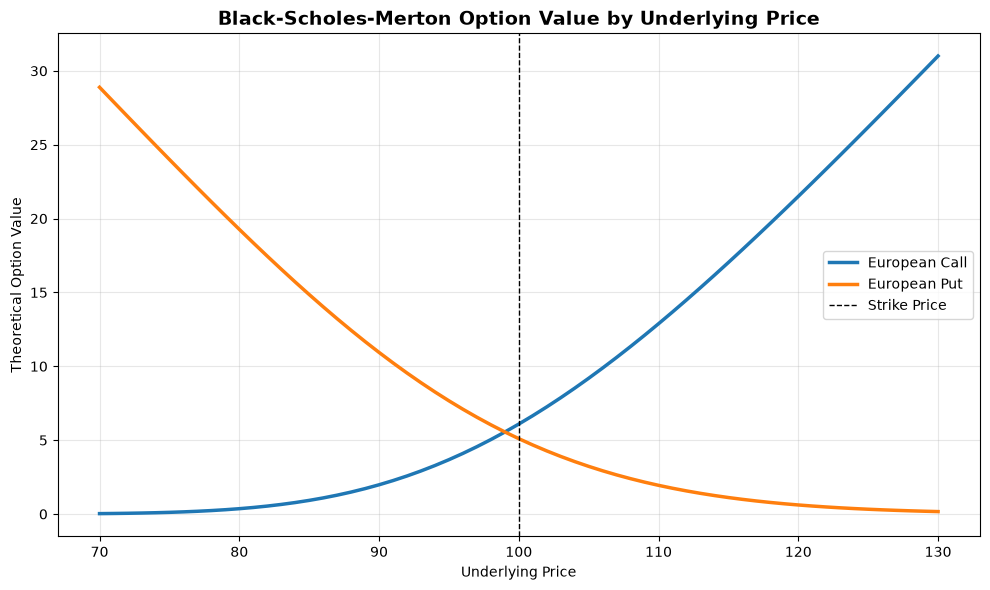

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    sensitivity_df["spot_price"],
    sensitivity_df["call_price"],
    label="European Call",
    linewidth=2.5,
)

plt.plot(
    sensitivity_df["spot_price"],
    sensitivity_df["put_price"],
    label="European Put",
    linewidth=2.5,
)

plt.axvline(
    x=100,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Strike Price",
)

plt.title("Black-Scholes-Merton Option Value by Underlying Price", fontsize=14, fontweight="bold")
plt.xlabel("Underlying Price")
plt.ylabel("Theoretical Option Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../outputs/option_price_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
def implied_volatility(
    market_price,
    option_type,
    spot,
    strike,
    maturity,
    risk_free_rate,
    dividend_yield=0.0,
    tolerance=1e-8,
    max_iterations=200,
):
    """
    Calculates implied volatility using the bisection method.

    Parameters
    ----------
    market_price : float
        Observed market price of the option.
    option_type : str
        "call" or "put".
    """
    if option_type not in {"call", "put"}:
        raise ValueError("option_type must be 'call' or 'put'.")

    low_volatility = 1e-6
    high_volatility = 5.0

    for _ in range(max_iterations):
        volatility = (low_volatility + high_volatility) / 2

        model_result = black_scholes_merton(
            spot=spot,
            strike=strike,
            maturity=maturity,
            risk_free_rate=risk_free_rate,
            volatility=volatility,
            dividend_yield=dividend_yield,
        )

        model_price = model_result[f"{option_type}_price"]
        pricing_error = model_price - market_price

        if abs(pricing_error) < tolerance:
            return volatility

        if pricing_error > 0:
            high_volatility = volatility
        else:
            low_volatility = volatility

    raise RuntimeError("Implied volatility did not converge.")

In [12]:
known_volatility = 0.20

known_price = black_scholes_merton(
    spot=100.0,
    strike=100.0,
    maturity=0.5,
    risk_free_rate=0.03,
    volatility=known_volatility,
    dividend_yield=0.01,
)["call_price"]

recovered_volatility = implied_volatility(
    market_price=known_price,
    option_type="call",
    spot=100.0,
    strike=100.0,
    maturity=0.5,
    risk_free_rate=0.03,
    dividend_yield=0.01,
)

pd.Series(
    {
        "Known volatility": known_volatility,
        "Recovered implied volatility": recovered_volatility,
        "Difference": recovered_volatility - known_volatility,
    }
).round(10)

Known volatility                2.000000e-01
Recovered implied volatility    2.000000e-01
Difference                     -2.000000e-10
dtype: float64

In [13]:
strike_prices = np.arange(70, 131, 5)

synthetic_market_data = []

for strike in strike_prices:
    moneyness = strike / 100.0

    synthetic_volatility = 0.18 + 0.35 * (moneyness - 1.0) ** 2

    synthetic_call_price = black_scholes_merton(
        spot=100.0,
        strike=strike,
        maturity=0.5,
        risk_free_rate=0.03,
        volatility=synthetic_volatility,
        dividend_yield=0.01,
    )["call_price"]

    recovered_iv = implied_volatility(
        market_price=synthetic_call_price,
        option_type="call",
        spot=100.0,
        strike=strike,
        maturity=0.5,
        risk_free_rate=0.03,
        dividend_yield=0.01,
    )

    synthetic_market_data.append(
        {
            "strike": strike,
            "moneyness": moneyness,
            "synthetic_call_price": synthetic_call_price,
            "synthetic_implied_volatility": recovered_iv,
        }
    )

smile_df = pd.DataFrame(synthetic_market_data)

smile_df.round(4)

,strike,moneyness,synthetic_call_price,synthetic_implied_volatility
0,70,0.70,30.5721,0.2115
1,75,0.75,25.7001,0.2019
2,80,0.80,20.9143,0.1940
3,85,0.85,16.3196,0.1879
4,90,0.90,12.0882,0.1835
5,95,0.95,8.4342,0.1809
6,100,1.00,5.5344,0.1800
7,105,1.05,3.4419,0.1809
8,110,1.10,2.0651,0.1835
9,115,1.15,1.2263,0.1879


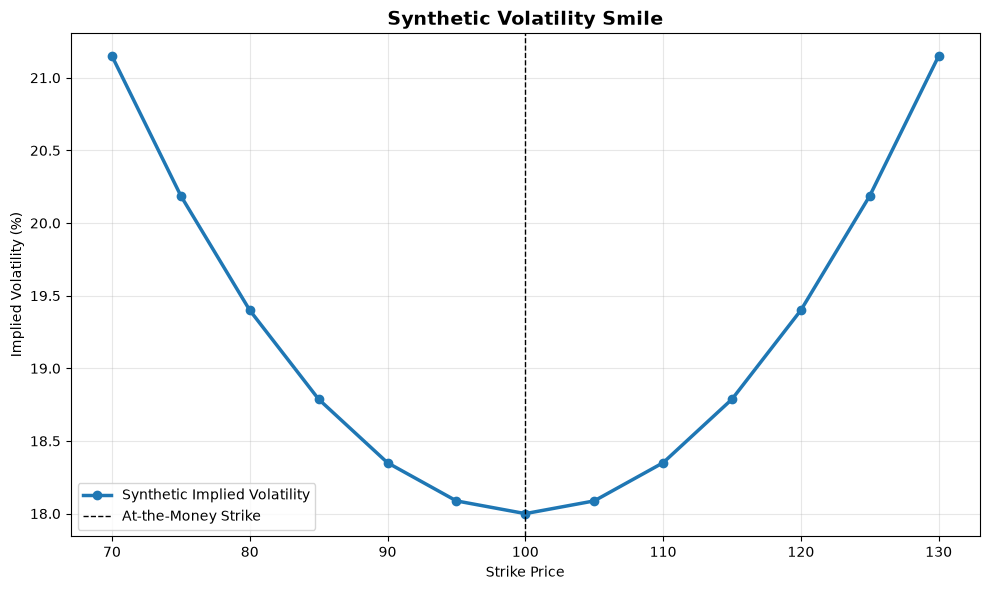

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    smile_df["strike"],
    smile_df["synthetic_implied_volatility"] * 100,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Synthetic Implied Volatility",
)

plt.axvline(
    x=100,
    color="black",
    linestyle="--",
    linewidth=1,
    label="At-the-Money Strike",
)

plt.title("Synthetic Volatility Smile", fontsize=14, fontweight="bold")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../outputs/synthetic_volatility_smile.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
def simulate_delta_hedge(
    initial_spot=100.0,
    strike=100.0,
    maturity=0.5,
    risk_free_rate=0.03,
    volatility=0.20,
    dividend_yield=0.01,
    trading_days_per_year=252,
    transaction_cost_rate=0.001,
    random_seed=42,
):
    """
    Simulates a discrete delta hedge for one short European call option.

    Transaction costs are applied as a percentage of the traded underlying value.
    """
    np.random.seed(random_seed)

    number_of_steps = int(maturity * trading_days_per_year)
    time_step = maturity / number_of_steps

    time_grid = np.linspace(0, maturity, number_of_steps + 1)
    spot_path = np.zeros(number_of_steps + 1)
    spot_path[0] = initial_spot

    for step in range(1, number_of_steps + 1):
        random_shock = np.random.normal()

        spot_path[step] = spot_path[step - 1] * np.exp(
            (risk_free_rate - dividend_yield - 0.5 * volatility**2) * time_step
            + volatility * np.sqrt(time_step) * random_shock
        )

    initial_option_price = black_scholes_merton(
        spot=initial_spot,
        strike=strike,
        maturity=maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )["call_price"]

    initial_delta = black_scholes_greeks(
        spot=initial_spot,
        strike=strike,
        maturity=maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )["call_delta"]

    shares_held = initial_delta
    cash_account = initial_option_price - shares_held * initial_spot
    cumulative_transaction_costs = shares_held * initial_spot * transaction_cost_rate

    hedge_history = []

    for step in range(number_of_steps):
        current_time = time_grid[step]
        remaining_maturity = maturity - current_time
        current_spot = spot_path[step]

        current_delta = black_scholes_greeks(
            spot=current_spot,
            strike=strike,
            maturity=remaining_maturity,
            risk_free_rate=risk_free_rate,
            volatility=volatility,
            dividend_yield=dividend_yield,
        )["call_delta"]

        shares_to_trade = current_delta - shares_held
        transaction_cost = abs(shares_to_trade) * current_spot * transaction_cost_rate

        cash_account = cash_account * np.exp(risk_free_rate * time_step)
        cash_account -= shares_to_trade * current_spot
        cash_account -= transaction_cost

        shares_held = current_delta
        cumulative_transaction_costs += transaction_cost

        portfolio_value = shares_held * current_spot + cash_account

        hedge_history.append(
            {
                "time": current_time,
                "spot_price": current_spot,
                "delta": current_delta,
                "shares_held": shares_held,
                "cash_account": cash_account,
                "portfolio_value": portfolio_value,
                "cumulative_transaction_costs": cumulative_transaction_costs,
            }
        )

    final_spot = spot_path[-1]
    option_payoff = max(final_spot - strike, 0.0)

    final_portfolio_value = shares_held * final_spot + cash_account * np.exp(risk_free_rate * time_step)
    hedge_error = final_portfolio_value - option_payoff

    return pd.DataFrame(hedge_history), {
        "final_spot": final_spot,
        "option_payoff": option_payoff,
        "final_portfolio_value": final_portfolio_value,
        "cumulative_transaction_costs": cumulative_transaction_costs,
        "hedge_error": hedge_error,
    }

In [16]:
hedge_history, hedge_summary = simulate_delta_hedge(
    initial_spot=100.0,
    strike=100.0,
    maturity=0.5,
    risk_free_rate=0.03,
    volatility=0.20,
    dividend_yield=0.01,
    transaction_cost_rate=0.001,
    random_seed=42,
)

pd.Series(hedge_summary).round(4)

final_spot                      91.7428
option_payoff                    0.0000
final_portfolio_value           -0.1274
cumulative_transaction_costs     0.2656
hedge_error                     -0.1274
dtype: float64

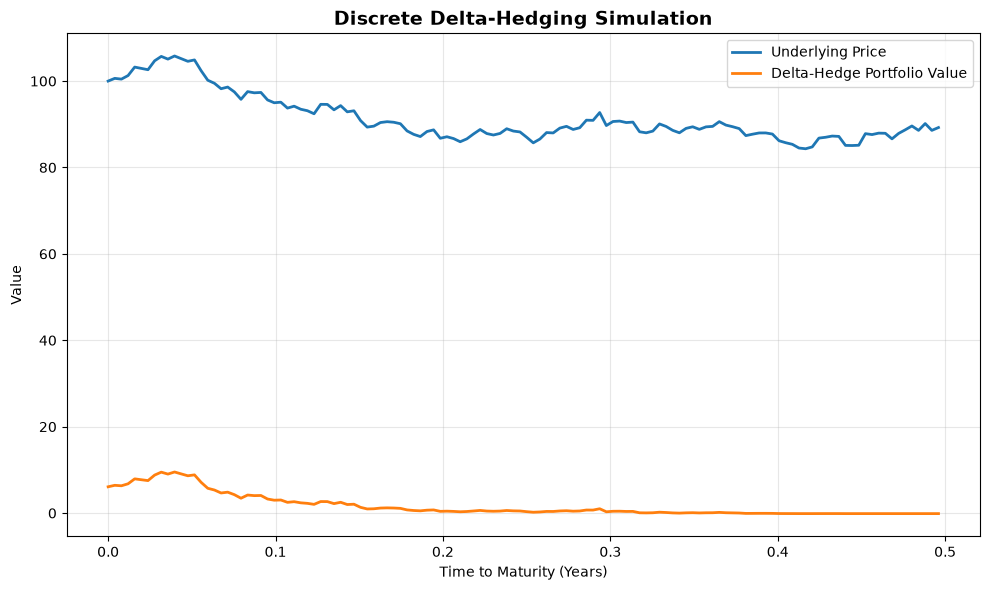

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    hedge_history["time"],
    hedge_history["spot_price"],
    label="Underlying Price",
    linewidth=2,
)

plt.plot(
    hedge_history["time"],
    hedge_history["portfolio_value"],
    label="Delta-Hedge Portfolio Value",
    linewidth=2,
)

plt.title("Discrete Delta-Hedging Simulation", fontsize=14, fontweight="bold")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../outputs/delta_hedging_simulation.png", dpi=300, bbox_inches="tight")
plt.show()